# MWE: a scene that rotates between two epochs

Dusty pinwheels such as WR 104 rotate with their binary's orbit, so two observations months apart see the same spiral turned by some angle. If the angle is known, from the orbit, the two epochs can be fitted with one image, doubling the data behind it. If it is not, it can be fitted too.

This notebook simulates AMI-like data (`virgil.coverage.ami_grid_record`) of a spiral around a star at two epochs, with the spiral turned by 60° between them. It reconstructs one image from both epochs with the rotation known and compares it with the image from the first epoch alone. It then reconstructs the image again with the rotation unknown: a coarse scan over angles finds roughly where it is, and the image is then reconstructed with the angle as a free parameter. Two tools do the work. `fit` accepts a model function that returns one model per dataset, sharing their parameters. `virgil.models.Rotated` turns any model on the sky by a fittable angle.

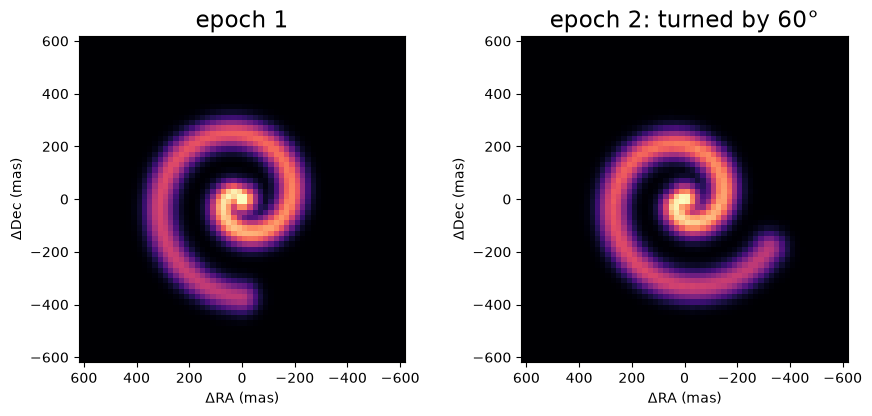

In [1]:
import sys
import warnings
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from tqdm.auto import tqdm

from virgil.coverage import ami_grid_record
from virgil.fitting import fit
from virgil.angles import AngleVector
from virgil.imaging import MaxEntropy, beam, image_priors, l_curve, starting_image
from virgil.models import Image, PointSource, Rotated, System
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import spiral

npix, scale = 62, 20.0
fov = npix * scale
truth_image = spiral(npix, scale, step_mas=250.0, width_mas=40.0, turns=1.5, fade_mas=500.0)
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=0.03))
truths = [truth, Rotated(truth, 60.0)]
epochs = [
    OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=roll)).with_model(model, key=jax.random.PRNGKey(k))
    for k, (roll, model) in enumerate(zip((-6.9, 41.0), truths))
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, model, title in zip(axes, (truth.env, Rotated(truth.env, 60.0)), ("epoch 1", "epoch 2: turned by 60°")):
    plot_model(model, fov_mas=fov, npix=npix, ax=ax, title=title)
plt.tight_layout()
plt.show()

## Both epochs with a known rotation

The model is a function of the image's parameters, returning the scene for the first epoch and a `Rotated` copy for the second. `l_curve` (and so `fit`) evaluates each model against its own dataset, and the maximum-entropy regulariser acts on the first. A function model has no template to start from, so the starting values come from `starting_image`'s model through `init`. For comparison, the first epoch is also fitted alone, at the same weight.

In [2]:
start = starting_image(epochs[0], largest_mas=fov)
priors = image_priors(start) | {"env.flux": dist.LogUniform(1e-3, 2.0)}
init = {path: start.get(path) for path in priors}


def two_epochs(spin=60.0, **params):
    scene = start.set(list(params), list(params.values()))
    return [scene, Rotated(scene, spin)]


curve = l_curve(two_epochs, priors, epochs, MaxEntropy(1.0, path="env"), jnp.logspace(1, 4, 7), init=init)
chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy() or curve.corner()))))
weight = float(curve.weights[chosen])
joint = curve.results[chosen]
single = fit(start, priors, epochs[0], [MaxEntropy(weight, path="env")])
print(f"weight {weight:.3g}; chi2 per point by epoch: {', '.join(f'{c:.2f}' for c in curve.chi2_red[chosen])}")

/var/tmp/jobfs/virgil/src/virgil/imaging.py:1904: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps, the step limit; raise max_steps.
  result = fit(


weight 100; chi2 per point by epoch: 0.95, 0.99


## One epoch against two

The truth, the reconstruction from the first epoch alone and the joint reconstruction, each with its beam shaded, and below them their signed differences from the truth. These are not z-scores, because a MAP image has no uncertainties. With twice the data, the joint image follows more of the outer winding, out to its tip. At the discrepancy weight both images are somewhat beaded, as maximum-entropy images tend to be when the data are fitted down to the noise.

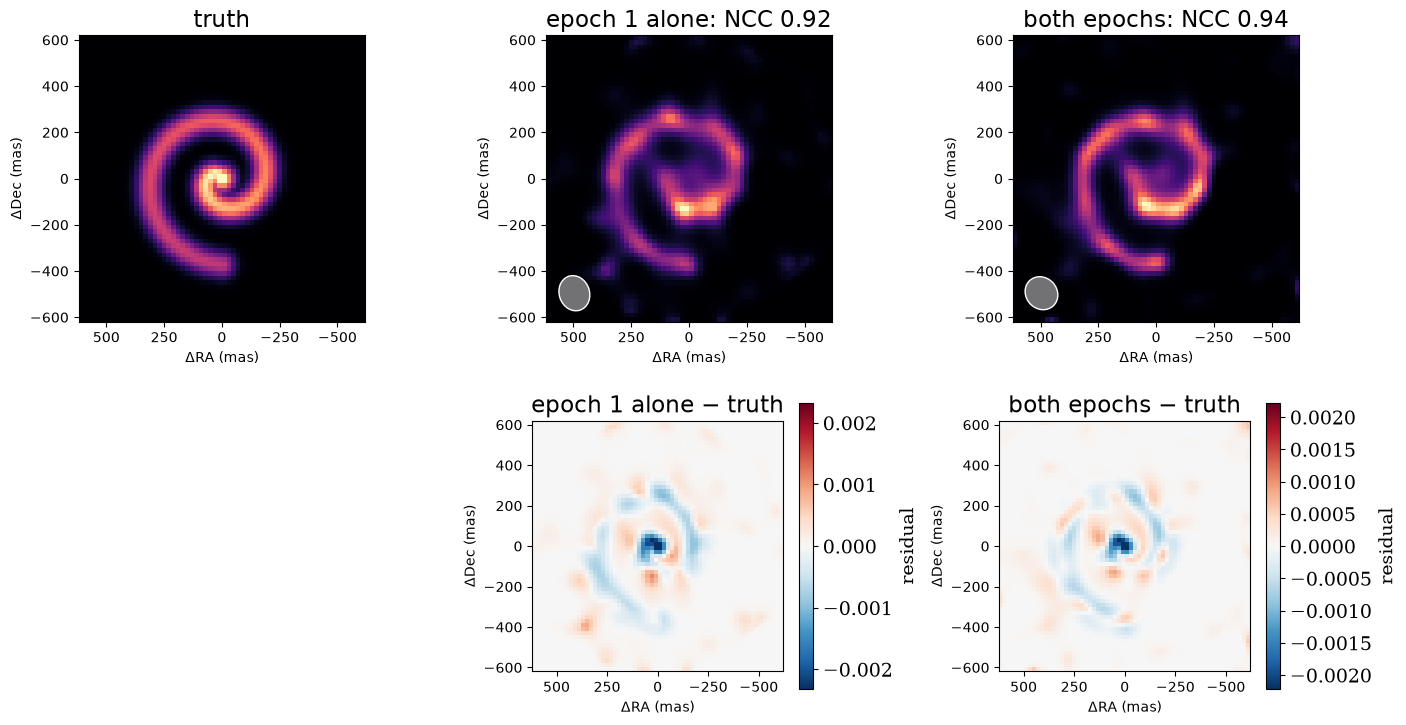

In [3]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (model, data, name) in enumerate([(single.model, epochs[0], "epoch 1 alone"), (joint.model[0], epochs, "both epochs")], start=1):
    image = model.env.render(npix, fov)
    plot_model(model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(image, truth_image):.2f}", beam=beam(data))
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title=f"{name} − truth")
plt.tight_layout()
plt.show()

## An unknown rotation: a coarse scan

When the angle is unknown, the loss can have several minima in it, for example at 180° from the truth for a nearly point-symmetric scene. A local fit started at the wrong angle can then get stuck. So the angle is first scanned on a coarse grid, fitting the image at each fixed angle (warm-started from the first epoch's image, and with a step limit, since only the ranking matters). For an Archimedean spiral the scan has to break a further near-degeneracy: turning the spiral by Δθ looks like expanding it by Δθ/2π of a winding. Only its inner and outer ends, and the fading of its brightness, tell the two apart.

angle scan:   0%|          | 0/24 [00:00<?, ?it/s]

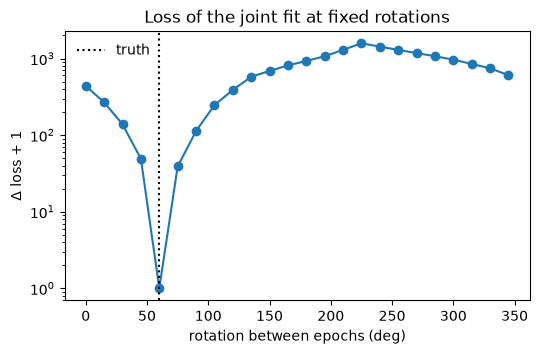

In [4]:
spins = jnp.arange(0.0, 360.0, 15.0)
losses = []
with warnings.catch_warnings():  # the step limit is deliberate
    warnings.simplefilter("ignore", RuntimeWarning)
    for spin in tqdm(spins, desc="angle scan"):
        result = fit(lambda **p: two_epochs(spin=float(spin), **p), priors, epochs, [MaxEntropy(weight, path="env")], init=single.values, max_steps=300)
        losses.append(result.info["loss"])
losses = jnp.array(losses)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(spins, losses - losses.min() + 1.0, "o-")
ax.axvline(60.0, color="k", ls=":", label="truth")
ax.set(xlabel="rotation between epochs (deg)", ylabel="Δ loss + 1", title="Loss of the joint fit at fixed rotations", yscale="log")
ax.legend(frameon=False)
plt.show()

## Reconstructing the image with the angle free

The image is now reconstructed exactly as with the known angle, except that the angle is a free parameter with an `AngleVector` prior on `"spin"` (uniform on the circle, with no edge at 0°/360°), starting from the best angle in the scan. `l_curve` sweeps the weight, refitting the image and the angle together at every step, and the weight is again chosen by the discrepancy principle. The angle is an ordinary traceable parameter: `Rotated` turns the uv coordinates at which the scene is evaluated, so its gradient is exact. The cost is that the second epoch's visibilities come from the direct Fourier transform, not from the faster matrix Fourier transform on the data's lattice.

In [5]:
best = float(spins[jnp.argmin(losses)])
free_curve = l_curve(two_epochs, priors | {"spin": AngleVector()}, epochs, MaxEntropy(1.0, path="env"), jnp.logspace(1, 4, 7), init=single.values | {"spin": best})
free_chosen = int(jnp.argmin(jnp.abs(jnp.log(free_curve.weights) - jnp.log(free_curve.discrepancy() or free_curve.corner()))))
free = free_curve.results[free_chosen]
print(f"scan: {best:.0f}°; weight {float(free_curve.weights[free_chosen]):.3g}; fitted rotation {float(free.values['spin']):.2f}° (truth 60°)")
print(f"chi2 per point by epoch: {', '.join(f'{c:.2f}' for c in free_curve.chi2_red[free_chosen])}")

/var/tmp/jobfs/virgil/src/virgil/imaging.py:1904: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps, the step limit; raise max_steps.
  result = fit(


scan: 60°; weight 100; fitted rotation 58.73° (truth 60°)
chi2 per point by epoch: 0.95, 0.99


## Known against fitted rotation

The truth, the joint reconstruction with the rotation known and the one with the rotation fitted, with the beam shaded, and below them their signed differences from the truth (not z-scores). The two reconstructions are nearly the same, because the fitted angle is within a fraction of a degree of the truth. At a 600 mas radius that is less than a pixel.

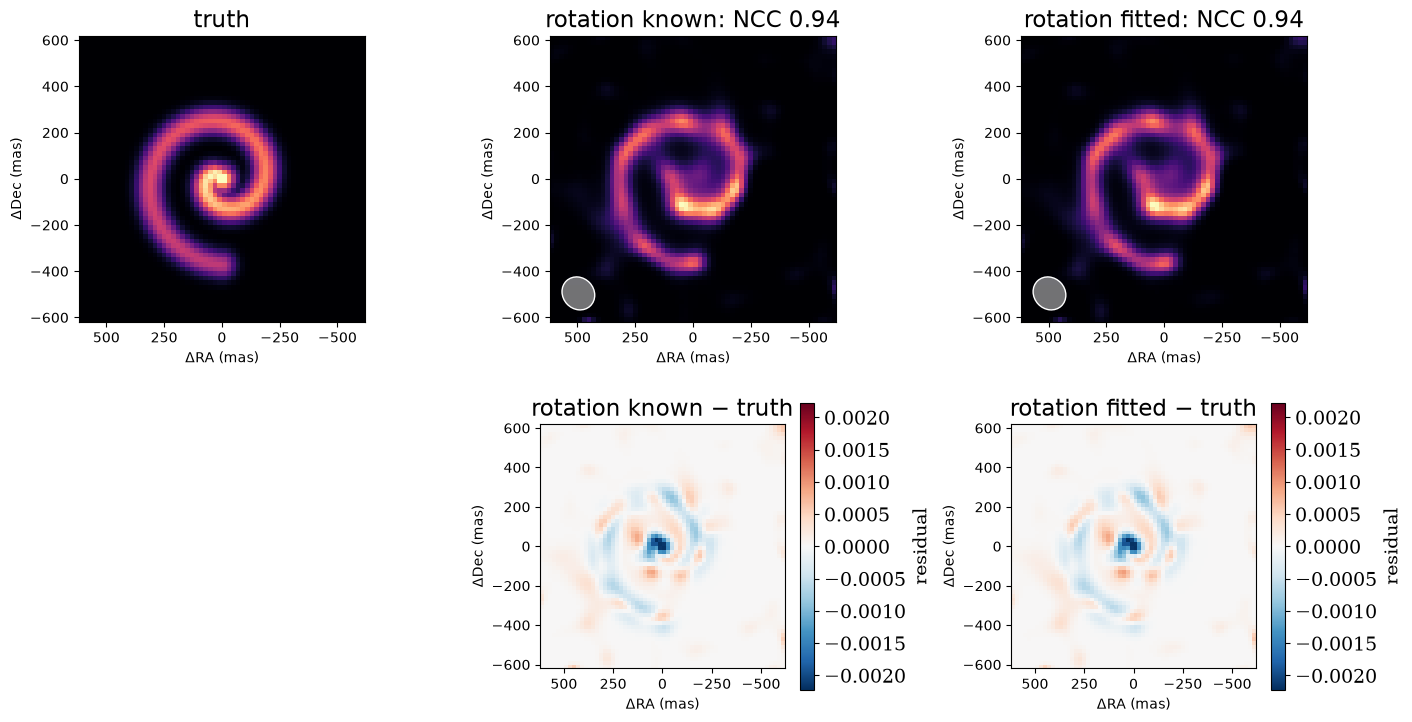

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (model, name) in enumerate([(joint.model[0], "rotation known"), (free.model[0], "rotation fitted")], start=1):
    image = model.env.render(npix, fov)
    plot_model(model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(image, truth_image):.2f}", beam=beam(epochs))
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title=f"{name} − truth")
plt.tight_layout()
plt.show()

## Summary

A model function that returns one model per dataset lets `fit` and `l_curve` fit several epochs of a changing scene with shared parameters, and `Rotated` turns a scene by an angle that can be fixed or fitted. With the rotation known, two epochs give a sharper image than one. With it unknown, a coarse scan over the angle followed by a reconstruction with the angle free recovers both the angle, to a fraction of a degree, and an image as good as the one made with the angle known. The same pattern covers other changes between epochs, such as a companion's orbital motion or an expanding shell, by changing what the function does to the second epoch's model.